In [1]:
import pandas as pd
import numpy as np
from tqdm import tqdm
from time import time
import hexaly.optimizer as hexaly
from itertools import product
import matplotlib.pyplot as plt
import sys
import pickle

In [2]:
start_time = time()

In [ ]:
hexaly.HxVersion.license_content = "LICENSE_KEY = ED3A-2222-89F4B124-770D-60A55B936308D780-9506208B36204986-9B3E-E289-C66E"

In [4]:
# with open('x.pkl', 'rb') as f:
#     x_initial_cg_cplex = pickle.load(f)

# # print(x_initial_cg_cplex)

In [5]:
def display_callback(optimizer, event_type):
    if event_type == hexaly.HxCallbackType.DISPLAY:
        solution = optimizer.solution
        if optimizer.model.nb_objectives > 0:
            objective_expr = optimizer.model.objectives[0]
            objective_value = solution.get_value(objective_expr)
            objective_bound = solution.get_objective_bound(0)
            optimality_gap = solution.get_objective_gap(0)
            print(f"Objective Value: {objective_value}")
            print(f"Objective Bound: {objective_bound}")
            print(f"Optimality Gap: {optimality_gap}")
        else:
            print("No objectives defined in the model.")

# Defining the speed processing of each type of station

In [6]:
#GLOBAL VARIABLES
STATIC_SPEED = 37700
PALETTE_SPEED = 57200
DYNAMIC_SPEED = 83200

# Reduce memory function on data frames

In [7]:
#function  to reduce the memory usage
def reduce_mem_usage(df, verbose=False):
    numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
    start_mem = df.memory_usage().sum() / 1024**2
    for col in df.columns:
        col_type = df[col].dtypes
        if col_type in numerics:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)  
            else:
                if c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)    
    end_mem = df.memory_usage().sum() / 1024**2
    if verbose:
        print('Mem. usage decreased to {:5.2f} Mb ({:.1f}% reduction)'.format(end_mem, 100 * (start_mem - end_mem) / start_mem))
    return df

# Read client file and clean the data

In [ ]:
data_df_initial= pd.read_csv(r"C:\Users\ebelul\Downloads\CSLAP_Project_All\Heuristic_Connex_Set_Project\data\BERNER_ORDER_LINES_09-12.csv", sep=';')[['PRODUCT','ORDER','STATION']].drop_duplicates().dropna()#, nrows=20000)

#Calculate the unique number of product per station
unique_counts = data_df_initial[['PRODUCT','STATION']].groupby('PRODUCT')['STATION'].nunique().reset_index(name='numb_stat_per_prod')
#Merging the count back to the original dataframe
data_df_initial = data_df_initial.merge(unique_counts, on='PRODUCT', how='left')

#Updating the product assignment with the last station they correspond
# Step 1: Identify products with numb_stat_per_prod > 1.
products_with_multiple_stations = data_df_initial[data_df_initial['numb_stat_per_prod'] > 1]['PRODUCT'].unique()

# Step 2: For these products, find the maximum order ID and the corresponding station ID.
max_order_stations = data_df_initial[data_df_initial['PRODUCT'].isin(products_with_multiple_stations)] \
    .sort_values(by='ORDER', ascending=False) \
    .drop_duplicates(subset=['PRODUCT'], keep='first')[['PRODUCT', 'STATION']]

# Step 3: Update the station ID for all occurrences of these products.
# First, merge this information back to the original df_order.
data_df_initial = data_df_initial.merge(max_order_stations, on='PRODUCT', how='left', suffixes=('', '_max_order'))

# If STATION_max_order is not NaN (i.e., for products with multiple stations), update the STATION column.
data_df_initial['STATION'] = data_df_initial.apply(lambda x: x['STATION_max_order'] if pd.notna(x['STATION_max_order']) else x['STATION'], axis=1)

# Drop the temporary STATION_max_order column as it's no longer needed.
data_df_initial.drop(columns=['STATION_max_order', 'numb_stat_per_prod'], inplace=True)

data_df_new = data_df_initial.copy()

# This is a filetering of data for testing with CG

In [9]:
#data_df_filter = data_df_new.copy()
data_df_new['Product_Frequency'] = data_df_new.groupby('PRODUCT')['ORDER'].transform('count')
product_test_list = np.unique(data_df_new[data_df_new['Product_Frequency']>2400]['PRODUCT'])
#Remove orders that contain only one product
# Calculate the number of unique 'PRODUCT' values for each 'ORDER'
order_product_counts = data_df_new.groupby('ORDER')['PRODUCT'].nunique()

# Filter 'ORDER's where the count of unique 'PRODUCT' values is more than 3
orders_to_keep = order_product_counts[order_product_counts > 50].index

# Filter the original DataFrame to keep only those rows with 'ORDER's in 'orders_to_keep'
data_df_new = data_df_new[data_df_new['ORDER'].isin(orders_to_keep)]
data_df_new = data_df_new[data_df_new['PRODUCT'].isin(product_test_list)]

# Remove stations as required and filterout orders that have only 1 product

In [10]:
stations_not_included = ['01.Z8','01.15','01.GED']
#Filter and count occurrences at the same time
data_df_new = data_df_new[~(data_df_new['STATION'].isin(stations_not_included))]
data_df_new.loc[data_df_new['STATION'] == '01.GE4', 'STATION'] = '01.E4'
# Calculate the total number of unique orders for setting the threshold
total_unique_orders = data_df_new['ORDER'].nunique()

# Count the number of 'Location_ID' for each STATION
#Calculate the unique number of product per station
total_number_of_location_per_station = data_df_new.groupby('STATION')['PRODUCT'].nunique().to_dict()


# Count the number of initial lines for each STATION
#Calculate number of product per station
station_lines_initial = data_df_new.groupby('STATION')['PRODUCT'].count().to_dict()

#Calculate the frequency for each product
#data_df_new['Product_Frequency'] = data_df_new.groupby('PRODUCT')['ORDER'].transform('count')


stations = data_df_new['STATION'].unique().astype(str)

# Categorise stations based on their type

In [11]:
static_stations = ['01.E4','01.31','01.30']
palette_stations = ['01.01','01.02','01.03','01.04','01.05']
union_stat = static_stations + palette_stations
dynamic_stations = np.array(data_df_new[~(data_df_new['STATION'].isin(union_stat))]['STATION'].drop_duplicates())

In [12]:
print(total_number_of_location_per_station)

{'01.06': 3, '01.07': 4, '01.08': 5, '01.09': 1, '01.10': 2, '01.11': 2, '01.12': 1, '01.13': 4, '01.22': 1, '01.24': 1, '01.25': 1}


# Specify the speed of processing on each station based on their type and the numbre of locations they have

In [13]:
speed = {s:STATIC_SPEED/total_number_of_location_per_station[s] for s in static_stations if s in stations}
speed.update({s:PALETTE_SPEED/total_number_of_location_per_station[s] for s in palette_stations if s in stations})
speed.update({s:DYNAMIC_SPEED/total_number_of_location_per_station[s] for s in dynamic_stations if s in stations})

In [14]:
print(len(data_df_new))
print(len(np.unique(data_df_new['PRODUCT'].values)))
print(len(np.unique(data_df_new['ORDER'].values)))
print(len(np.unique(data_df_new['STATION'].values)))
print(sum(list(total_number_of_location_per_station.values())))

1380
25
601
11
25


In [15]:
print(speed)

{'01.24': 83200.0, '01.13': 20800.0, '01.10': 41600.0, '01.08': 16640.0, '01.09': 83200.0, '01.07': 20800.0, '01.11': 41600.0, '01.22': 83200.0, '01.06': 27733.333333333332, '01.12': 83200.0, '01.25': 83200.0}


In [16]:
print(data_df_new)

           PRODUCT       ORDER STATION  Product_Frequency
11180      1000381  8076574253   01.24               2826
11392      1000381  8076591877   01.24               2826
11458      1000381  8076594519   01.24               2826
11528      1000381  8076597581   01.24               2826
11681      1000381  8076603981   01.24               2826
...            ...         ...     ...                ...
1462291  857386-10  8076708377   01.11               4154
1462324  857386-10  8076711347   01.11               4154
1462332  857386-10  8076711743   01.11               4154
1462380  857386-10  8076715637   01.11               4154
1462498  857386-10  8076726149   01.11               4154

[1380 rows x 4 columns]


# Fromat the input data in the form of product and the list of orders it is in

In [17]:
# data_df_new = pd.read_csv("..\Data\df_order_new.csv")[['Product','ORDER','MAJ_STAT']].drop_duplicates().dropna()
# data_df_new.rename(columns= {'Product': 'PRODUCT', 'MAJ_STAT':'STATION'}, inplace=True)
# data_df_new = reduce_mem_usage(data_df_new, verbose=False)

In [18]:
df_product = data_df_new.groupby('PRODUCT').agg({
    'ORDER': list,  # Aggregate orders into a list
    'STATION': 'first'  # Assuming each product is assigned to a unique station, we take the first occurrence
    #'Product_Frequency': 'first'
}).reset_index().rename(columns={'ORDER': 'ORDER_LIST'})
df_product['Product_Frequency'] = df_product['ORDER_LIST'].apply(len)
# df_product = pd.merge(df_product, data_df_filter[['PRODUCT', 'Product_Frequency']].drop_duplicates(), 
#                      on='PRODUCT', how='left')
df_product = df_product.sort_values(by='Product_Frequency', ascending=False)
df_product.set_index('PRODUCT',inplace=True)
print(df_product)

                                                   ORDER_LIST STATION  \
PRODUCT                                                                 
4375-100    [8076384989, 8076385666, 8076385985, 807638871...   01.25   
38278       [8076392174, 8076393997, 8076394958, 807639634...   01.06   
369964-100  [8076389369, 8076394955, 8076394958, 807639742...   01.13   
367176      [8076388715, 8076393608, 8076396346, 807640118...   01.07   
405732      [8076384889, 8076392174, 8076392467, 807639425...   01.06   
857386-10   [8076389369, 8076389563, 8076394254, 807640490...   01.11   
142454      [8076386711, 8076386713, 8076386715, 807638672...   01.13   
369974-100  [8076389776, 8076390499, 8076393480, 807639399...   01.06   
201071      [8076388715, 8076392176, 8076393608, 807639634...   01.07   
199790      [8076389992, 8076392176, 8076393608, 807640259...   01.09   
339281      [8076384889, 8076386711, 8076386713, 807638671...   01.11   
335506      [8076396346, 8076403698, 8076406701, 80

In [19]:
# #low_freq_prod = df_product[(df_product['Product_Frequency']<=4) & (df_product['STATION'].isin(static_stations))].index
# low_freq_prod = df_product[(df_product['Product_Frequency']<=179)].index
# df_product = df_product[~df_product.index.isin(low_freq_prod)]
# print(len(low_freq_prod))

# Dataframe the presents unique orders with the list of products they contain

In [20]:
data_df_new2 = data_df_new[['PRODUCT','ORDER']].drop_duplicates()
df_order = data_df_new2[data_df_new2['PRODUCT'].isin(df_product.index)].groupby('ORDER')['PRODUCT'].apply(list).reset_index(name='PRODUCT_LIST')
df_order.set_index('ORDER',inplace=True)

# Define the locations available on each station based on the products that will go through the main process of assignment

In [21]:
total_number_of_location_per_station_2 = df_product.groupby('STATION').size().to_dict()
print(total_number_of_location_per_station_2)

{'01.06': 3, '01.07': 4, '01.08': 5, '01.09': 1, '01.10': 2, '01.11': 2, '01.12': 1, '01.13': 4, '01.22': 1, '01.24': 1, '01.25': 1}


In [22]:
# Convert df_product and speed data into dictionaries for quick lookup
product_frequency = (
    df_product[['Product_Frequency']]
    .set_index(df_product.index)['Product_Frequency']
    .to_dict()
)
# Assuming data_df_new contains PRODUCT and STATION mapping directly
product_to_station = (
    df_product[['STATION']]
    .set_index(df_product.index)['STATION']
    .to_dict()
)

In [23]:
print(len(product_frequency))
print(len(product_to_station))

25
25


# Provide the initital workload of each station that should be respected during the assignment from the solver as a constraint

In [24]:
products = df_product.index
orders = list(df_product['ORDER_LIST'].explode().unique())
data_group = data_df_new[data_df_new['PRODUCT'].isin(df_product.index)]

In [25]:
print(len(orders))

601


In [26]:
total_length = {s:0 for s in stations}
count = {s:0 for s in stations}
for p in products:
    for s in stations:
        if product_to_station[p] == s:
                    total_length[s] += product_frequency[p] / speed[s]
                    count[s]+=1
        
print(total_length)

{np.str_('01.24'): 0.0002644230769230769, np.str_('01.13'): 0.01139423076923077, np.str_('01.10'): 0.0006971153846153846, np.str_('01.08'): 0.009495192307692307, np.str_('01.09'): 0.0006490384615384615, np.str_('01.07'): 0.009903846153846154, np.str_('01.11'): 0.0031730769230769234, np.str_('01.22'): 0.000576923076923077, np.str_('01.06'): 0.009735576923076923, np.str_('01.12'): 0.00037259615384615386, np.str_('01.25'): 0.0023197115384615383}


In [27]:
for s in stations:    
    total_length[s] = 1.05*total_length[s]

In [28]:
print(sum(total_length[s] for s in stations))
print(sum(count[s] for s in stations))
print(sum(total_number_of_location_per_station_2[s] for s in stations))

0.05101081730769231
25
25


In [29]:
#Scale the workload coefficent to aviod numerical instabilities in the solver process
# Define scaling factors to normalize the right-hand side to 1.
# We also avoid division by zero by using a small tolerance.
scaling = { s: (1.0 / total_length[s] if total_length[s] > 1e-12 else 1.0) for s in stations }

In [30]:
data_df_new3 = data_df_new[['PRODUCT','STATION']].drop_duplicates()
df_station = data_df_new3[data_df_new3['PRODUCT'].isin(df_product.index)].groupby('STATION')['PRODUCT'].apply(list).reset_index(name='PRODUCT_ASSIGNED')
df_station.set_index('STATION',inplace=True)

# Generate the smooth start solution to provide to the solver

In [31]:
def generate_mip_start(df_station,product_to_index):
    # Approach is to initialize initial_solution_product_station and initial_solution_order_station
    initial_station_assignments_named = df_station['PRODUCT_ASSIGNED'].to_dict()

    initial_station_assignments_indices = {
    s: [product_to_index[p] for p in products]
    for s, products in initial_station_assignments_named.items()
    }
    
    return initial_station_assignments_indices

In [32]:
# def generate_mip_start(data_df):
#     # Approach is to initialize initial_solution_product_station and initial_solution_order_station
#     initial_solution_product_station = {}
#     initial_solution_order_station = {}

#     # For Product-Station Initialization
#     # Group by 'PRODUCT' and 'STATION', then take the first occurrence
#     product_station_group = data_df.groupby(['PRODUCT'])['STATION'].first().reset_index()
#     initial_solution_product_station = {(row['PRODUCT'], row['STATION']): 1 for index, row in product_station_group.iterrows()}

#     # For Order-Station Initialization
#     # Group by 'ORDER' and 'STATION', then take the first occurrence
#     order_station_group = data_df.groupby(['ORDER'])['STATION'].first().reset_index()
#     initial_solution_order_station = {(row['ORDER'], row['STATION']): 1 for index, row in order_station_group.iterrows()}

    
#     return initial_solution_product_station, initial_solution_order_station

# Check the feasibility of the smooth start solution

In [33]:
# def check_feasibility(
#     x, 
#     products, 
#     stations, 
#     total_number_of_location_per_station_2,  # dictionary: station -> max #products
#     total_length,                            # dictionary: station -> time capacity
#     df_product,                              # DataFrame with at least 'Product_Frequency'
#     speed                                    # dictionary: station -> picking speed
# ):
#     """
#     Checks whether a given assignment x[p,s] is feasible under:
#       1) Each product is assigned exactly once.
#       2) Station capacity does not exceed total_number_of_location_per_station_2[s].
#       3) Station picking-time constraint is not exceeded.
#     """
#     feasible = True

#     # 1) Check that each product is assigned to exactly one station
#     for p in products:
#         sum_assignments = sum(x.get((p, s), 0) for s in stations)
#         if abs(sum_assignments - 1) > 1e-9:
#             print(f"[Violation] Product {p} is assigned to {sum_assignments} stations (should be 1).")
#             feasible = False

#     # 2) Check station capacity constraints
#     for s in stations:
#         assigned_count = sum(x.get((p, s), 0) for p in products)
#         capacity = total_number_of_location_per_station_2.get(s, 0)
#         if assigned_count > capacity:
#             print(f"[Violation] Station {s} capacity exceeded: assigned {assigned_count} > capacity {capacity}.")
#             feasible = False

#     # 3) Check station picking-time constraints
#     for s in stations:
#         picking_time_used = 0.0
#         for p in products:
#             if x.get((p, s), 0) > 0.5:  # i.e., x[(p,s)] == 1
#                 product_freq = df_product.loc[p, 'Product_Frequency']
#                 picking_time_used += product_freq / speed[s]

#         if picking_time_used > 1.2*total_length[s]:
#             print(f"[Violation] Station {s} picking time exceeded: used {picking_time_used:.4f}"
#                   f" > capacity {total_length[s]:.4f}.")
#             feasible = False

#     if feasible:
#         print("No constraints violated. The solution is FEASIBLE!")
#     else:
#         print("Some constraints are violated. The solution is INFEASIBLE.")

#     return feasible


In [34]:
# x, z = generate_mip_start(data_group)
# feasible = check_feasibility(
#     x,
#     products=products,
#     stations=stations,
#     total_number_of_location_per_station_2=total_number_of_location_per_station_2,
#     total_length=total_length,
#     df_product=df_product,
#     speed=speed
# )

# Formulating and solving the model for the main data

In [35]:
with hexaly.HexalyOptimizer() as optimizer:
    #optimizer.param.time_limit = 72000
    model = optimizer.model
    optimizer.param.verbosity = 1
    optimizer.param.set_time_between_displays(60)
    optimizer.add_callback(hexaly.HxCallbackType.DISPLAY, display_callback)
    #optimizer.param.set_nb_threads(8)
    #change from product names to indexes to fit in the set variable 
    product_to_index = {p: idx for idx, p in enumerate(products)}

    
    # Set decision variable that shows the set of products assigned to each s
    station_products = {s: model.set(len(products)) for s in stations}

    # Constraint: Products assigned exactly once (partition)
    model.constraint(model.partition([station_products[s] for s in stations]))

    # Constraint: Maximum products per station
    for s in tqdm(stations):
        model.constraint(model.count(station_products[s]) <= total_number_of_location_per_station_2.get(s, 0))

    # Constraint: Workload limits per station
    for s in  tqdm(stations):
        workload_expr = model.sum(df_product.loc[p]['Product_Frequency']/speed[s] * model.contains(station_products[s], product_to_index[p]) for p in products)
        model.constraint(workload_expr <= total_length[s])

    # Objective: Minimize total number of station visits per order
    pbar = tqdm(total=len(orders) * len(stations), desc='Inner loop', leave=True)
    objective = 0
    for o in orders:
        prods_in_o = df_order.loc[o]['PRODUCT_LIST']
        for s in stations:   
            objective += model.sum(
                model.or_(*(model.contains(station_products[s], product_to_index[p]) for p in prods_in_o))
            )
            pbar.update(1)
    model.minimize(objective)

    model.close()

    # Generate the initial solution
    initial_station_assignments_indices = generate_mip_start(df_station,product_to_index)

    # Assign MIP start values to Hexaly variables
    for s in stations:
        for idx in initial_station_assignments_indices.get(s, []):
            station_products[s].value.add(idx) 
        
    optimizer.solve()

    station_assignment_results = {
    s: station_products[s].value for s in stations
    }
    
    index_to_product = {idx: p for p, idx in product_to_index.items()}
    
    station_assignments_named = {
        s: [index_to_product[idx] for idx in station_assignment_results[s]]
        for s in stations
    }

Inner loop:  72%|█████████████████████████████████████████████▌                 | 4781/6611 [00:00<00:00, 23503.68it/s]

Push initial solution 100%
Model:  expressions = 35761, decisions = 11, constraints = 23, objectives = 1
Param:  no time limit, no iteration limit, time between displays = 60

[objective direction ]:     minimize

[  0 sec,       0 itr]:         1209
[ optimality gap     ]:      100.00%
Objective Value: 1209
Objective Bound: 0
Optimality Gap: 1.0


Inner loop: 100%|███████████████████████████████████████████████████████████████| 6611/6611 [00:19<00:00, 23503.68it/s]

[ 60 sec, 8532750 itr]:         1097
Objective Value: 1097
Objective Bound: 889
Optimality Gap: 0.18960802187784867
[120 sec, 16762347 itr]:         1097
Objective Value: 1097
Objective Bound: 908
Optimality Gap: 0.1722880583409298
[180 sec, 25535057 itr]:         1097
Objective Value: 1097
Objective Bound: 932
Optimality Gap: 0.1504102096627165
[240 sec, 34483924 itr]:         1097
Objective Value: 1097
Objective Bound: 944
Optimality Gap: 0.13947128532360983
[300 sec, 42975615 itr]:         1097
Objective Value: 1097
Objective Bound: 970
Optimality Gap: 0.11577028258887875
[344 sec, 49460860 itr]:         1097
[ optimality gap      ]:           0%
Objective Value: 1097
Objective Bound: 1097
Optimality Gap: 0.0

49460860 iterations performed in 344 seconds

Optimal solution: 
  obj    =         1097
  gap    =           0%
  bounds =         1097


In [36]:
# # Initialize Hexaly optimizer
# with hexaly.HexalyOptimizer() as optimizer:
#     #optimizer.param.time_limit = 12000
#     model = optimizer.model
#     optimizer.param.verbosity = 1  
#     optimizer.param.nb_threads = 16
#     optimizer.param.set_time_between_displays(60)

#     #optimizer.add_callback(hexaly.HxCallbackType.DISPLAY, display_callback)

#     # Define decision variables
#     x = {(p, s): model.bool() for p in products for s in stations}
#     #z = {(o, s): model.float(0,1) for o in orders for s in stations}


#     # Set constraints
#     for p in tqdm(products, desc='Constraint Product', leave=True):
#         model.constraint(model.sum(x[p, s] for s in stations) == 1)

#     for s in tqdm(stations, desc='Constraint Stations', leave=True):
#         model.constraint(model.sum(x[p, s] for p in products) <= total_number_of_location_per_station_2.get(s, 0))
#         # Scaled workload constraint:
#         # model.constraint(
#         #     scaling[s] * model.sum(x[p, s] * df_product.loc[p]['Product_Frequency'] / speed[s]
#         #                            for p in products) <= 1
#         # )
#         model.constraint(model.sum(x[p, s] * df_product.loc[p]['Product_Frequency'] / speed[s]
#                                    for p in products) <= total_length[s])

#     # Progress bar for inner loop
#     pbar = tqdm(total=len(orders) * len(stations), desc='Inner loop', leave=True)

#     # Define the objective function
#     objective = 0
#     z = {}
#     for o in orders:
#         prods_in_o = df_order.loc[o]['PRODUCT_LIST']
#         for s in stations:
#             z[o, s] = 0
#             for p in prods_in_o:
#                 #z[o, s] = model.or_(x[p, s], z[o, s])  # Logical OR operation
#                 z[o, s] = model.max(x[p, s], z[o, s])
#             objective += z[o, s]
#             pbar.update(1)
#     model.minimize(objective)
#     model.close()

#     # Generate the initial solution
#     initial_solution_product_station, initial_solution_order_station = generate_mip_start(data_group)

#     # Assign initial solutions to the decision variables
#     for (p, s), value in tqdm(initial_solution_product_station.items()):
#         if (p, s) in x:
#             x[p, s].value = value  # Use the 'value' attribute to set initial values
#     # for (o, s), value in tqdm(initial_solution_order_station.items()):
#     #     if (o, s) in z:
#     #         z[o, s].value = value  
#     # print("Solver ready to start")
#     # Solve the model
#     optimizer.solve()

#     # Retrieve results
#     results_x = {(p, s): x[p, s].value for p in products for s in stations}

# # Output the total runtime
# #print(f"Total runtime: {time() - start_time} seconds")

# Retrive the assignment of products to station that the solver has made

In [37]:
product_station_df = pd.DataFrame([
    {'PRODUCT': product, 'StationID_P': station}
    for station, products in station_assignments_named.items()
    for product in products
])
product_station_df.to_csv(r'C:\ermal\notebooks\Correlated_Storage_Assignment_Problem\Notebooks\CSLAP_CG_vs_MILP\Sampled_data_CG_vs_MILP\product_assignment_group_sample_25_MILP_Hexaly_sets.csv')

In [38]:
# x_0 = np.empty((0,2))
# for (p, s), val in results_x.items():
#             if val:
#                 x_0 = np.vstack((x_0, [[p, s]]))

In [39]:
# print(len(x_0))

# Format the assignment of products in the form of a data frame and save it

In [40]:
# product_station_df = pd.DataFrame(x_0, columns=['PRODUCT', 'StationID_P']).drop_duplicates()
# #product_station_cg_df = pd.DataFrame(x_initial_cg_cplex, columns=['PRODUCT', 'StationID_P']).drop_duplicates()

# #order_station_df = pd.DataFrame(z_0, columns=['ORDER', 'StationID_O']).drop_duplicates()
# product_station_df.to_csv(r'C:\ermal\notebooks\Correlated_Storage_Assignment_Problem\Notebooks\CSLAP_CG_vs_MILP\Sampled_data_CG_vs_MILP\product_assignment_group_sample_25_MILP_Hexaly.csv')

# #product_station_df.to_csv(r'C:\ermal\notebooks\Correlated_Storage_Assignment_Problem\Notebooks\LocalSolver_version\Group_Results_1\product_assignment_group_localSolver_7_1.csv')
# #order_station_df.to_csv(r'C:\ermal\notebooks\Correlated_Storage_Assignment_Problem\Notebooks\LocalSolver_version\Group_Results_1\order_assignment_group_localSolver_1.csv')

In [41]:
end_time = time() - start_time
print(end_time)

377.52094054222107


# Check if the workload constraint is respected on the final assignment

In [42]:
# for s in stations:
#     # Calculate and print the value of the length constraint
#     length_constraint_value = sum(
#         results_x[p, s] * df_product[df_product['PRODUCT'] == p]['Product_Frequency'].values[0] / speed[s]
#         for p in products 
#     )
#     print(f"Length constraint value = {length_constraint_value}, Limit = {total_length[s]}, on station {s}")

# Analyse the assignment and comparisons with initial assignment

In [43]:
# stations_not_included = ['01.Z8']
# #Filter and count occurrences at the same time
# data_df_initial = data_df_initial[~(data_df_initial['STATION'].isin(stations_not_included))]
# data_df_initial.loc[data_df_initial['STATION'] == '01.GE4', 'STATION'] = '01.E4'

# data_df_initial['Product_Frequency'] = data_df_initial.groupby('PRODUCT')['ORDER'].transform('count')

In [44]:
df_final = pd.merge(data_df_new,product_station_df, on='PRODUCT',how='left')[['PRODUCT','STATION','StationID_P','ORDER']]
#df_final_cg = pd.merge(data_df_new,product_station_df, on='PRODUCT',how='left')[['PRODUCT','STATION','StationID_P','ORDER','Product_Frequency']]
df_final['StationID_P'].fillna(df_final['STATION'], inplace=True)
#df_final_cg['StationID_P'].fillna(df_final_cg['STATION'], inplace=True)
print(df_final)

        PRODUCT STATION StationID_P       ORDER
0       1000381   01.24       01.08  8076574253
1       1000381   01.24       01.08  8076591877
2       1000381   01.24       01.08  8076594519
3       1000381   01.24       01.08  8076597581
4       1000381   01.24       01.08  8076603981
...         ...     ...         ...         ...
1375  857386-10   01.11       01.06  8076708377
1376  857386-10   01.11       01.06  8076711347
1377  857386-10   01.11       01.06  8076711743
1378  857386-10   01.11       01.06  8076715637
1379  857386-10   01.11       01.06  8076726149

[1380 rows x 4 columns]


C:\Users\ebelul\AppData\Local\Temp\3\ipykernel_3648\503416846.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_final['StationID_P'].fillna(df_final['STATION'], inplace=True)


# Total and Mean number of order station passe

## Initial assignment

In [45]:
df_order_s1 = df_final[['STATION','ORDER']].drop_duplicates()
df_order_s1['cnt'] = df_order_s1.groupby('ORDER')['STATION'].transform('nunique')
df_order_s1_cnt = df_order_s1[['cnt','ORDER']].drop_duplicates()
s1 = df_order_s1_cnt['cnt'].sum()
m1 = df_order_s1_cnt['cnt'].mean()
print(s1,m1)

1209 2.011647254575707


## Solver assignment

In [46]:
df_order_s2 = df_final[['StationID_P','ORDER']].drop_duplicates()
df_order_s2['cnt'] = df_order_s2.groupby('ORDER')['StationID_P'].transform('nunique')
df_order_s2_cnt = df_order_s2[['cnt','ORDER']].drop_duplicates()
s2 = df_order_s2_cnt['cnt'].sum()
m2 = df_order_s2_cnt['cnt'].mean()
print(s2,m2)

1097 1.8252911813643926


In [47]:
df_order_s1_cnt = df_order_s1_cnt['cnt'].value_counts(dropna=False)
df_order_s2_cnt = df_order_s2_cnt['cnt'].value_counts(dropna=False)

# Function to visualise the number of orders that pass through a respective total number of stations

In [48]:
# Align the indices
def graph_1(df_order_s1_cnt,df_order_s2_cnt):
    all_indices = sorted(set(df_order_s1_cnt.index) | set(df_order_s2_cnt.index))  # Union of indices from both datasets
    df_order_s1_cnt = df_order_s1_cnt.reindex(all_indices).fillna(0)  # Reindex and fill missing values with 0
    df_order_s2_cnt = df_order_s2_cnt.reindex(all_indices).fillna(0)  # Reindex and fill missing values with 0
    
    print(all_indices)
    # Set up the figure and axis
    plt.figure(figsize=(10, 5))
    ax = plt.gca()
    
    
    # Width of the bars
    width = 0.35
    
    
    # Positions for the bars
    indices = np.arange(len(all_indices))
    
    
    # Plotting
    rects1 = ax.bar(indices - width/2, df_order_s1_cnt, width, label='OLD', alpha=0.6)
    rects2 = ax.bar(indices + width/2, df_order_s2_cnt, width, label='NEW', alpha=0.6)
    
    
    # Add labels and title
    plt.xlabel('Number of Stations')
    plt.ylabel('Number of Orders')
    plt.title('Number of Orders per Stations Numbers')
    
    
    # Add x-ticks and labels
    plt.xticks(indices, all_indices)
    # Add a legend
    plt.legend()
    #plt.savefig(NAME_OF_RUN+'_'+'number_of_orders_per_station_numbers.png')
    
    
    plt.show()

[1, 2, 3, 4, 5, 6]


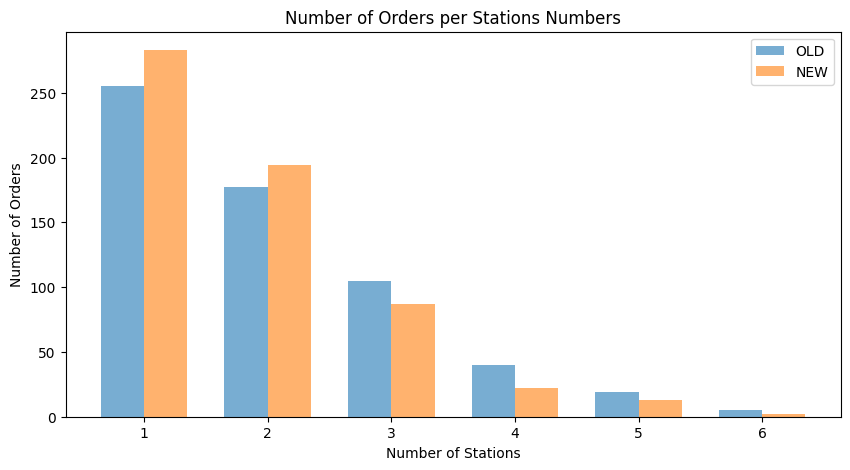

In [49]:
graph_1(df_order_s1_cnt,df_order_s2_cnt)

# Function to visualise the workload on each station

In [50]:
def plot_final(tmp_final,xlabel,ylabel,title, sort_by='STATION', ascending=True):


    # Set up the figure and axis
    plt.figure(figsize=(10, 5))
    ax = plt.gca()


    # Width of the bars
    width = 0.35
    
    # Sorting tmp_final based on the specified sort_by column
    tmp_final_sorted = tmp_final.sort_values(by=sort_by, ascending=ascending)


    # Positions for the bars
    stations = tmp_final['STATION'].astype(str).values
    indices = np.arange(len(stations))


    # Plotting
    rects1 = ax.bar(indices - width/2, tmp_final['cnt_lines'], width, label='OLD', alpha=0.6)
    rects2 = ax.bar(indices + width/2, tmp_final['cnt_lines_New'], width, label='NEW', alpha=0.6)


    # Add labels and title
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)


    # Add x-ticks and labels
    plt.xticks(indices, stations, rotation=45)


    # Add a legend
    plt.legend()


    #plt.savefig(NAME_OF_RUN+'_'+'number_of_lines_per_station.png')
    plt.show()

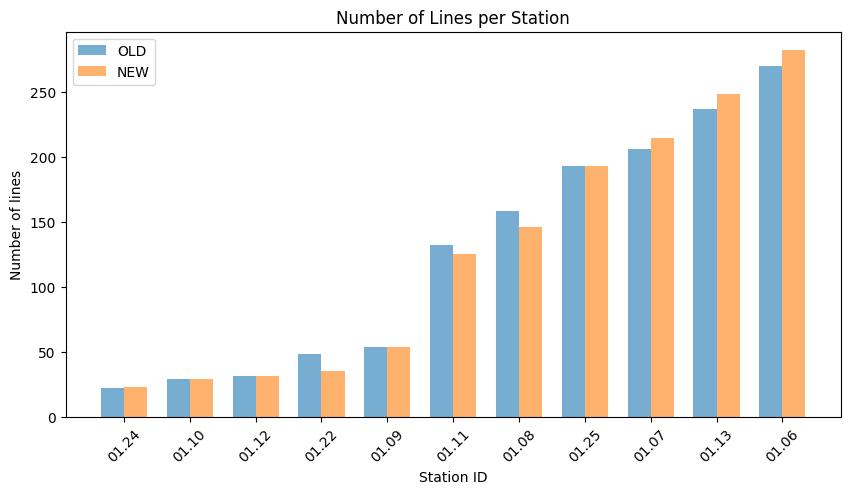

In [51]:
df_order_lines_plot = df_final.copy()
df_order_lines_plot['cnt_lines_New'] = df_order_lines_plot[['PRODUCT','StationID_P']].groupby('StationID_P').transform('count')
df_order_lines_plot['cnt_lines'] = df_order_lines_plot[['PRODUCT','STATION']].groupby('STATION').transform('count')
tmp_lines = df_order_lines_plot[['StationID_P','cnt_lines_New']].drop_duplicates()
tmp_lines.rename(columns={'StationID_P':'STATION'}, inplace=True)
tmp_lines = tmp_lines.merge(df_order_lines_plot[['STATION','cnt_lines']].drop_duplicates(), on='STATION', how='outer').fillna(0)
tmp_lines.sort_values(by='cnt_lines', ascending=True, inplace=True)
xlabel = 'Station ID'
ylabel = 'Number of lines'
title = 'Number of Lines per Station'
plot_final(tmp_lines, xlabel, ylabel, title, sort_by='cnt_lines', ascending=False)

# Visualising the number of products assigned on each station

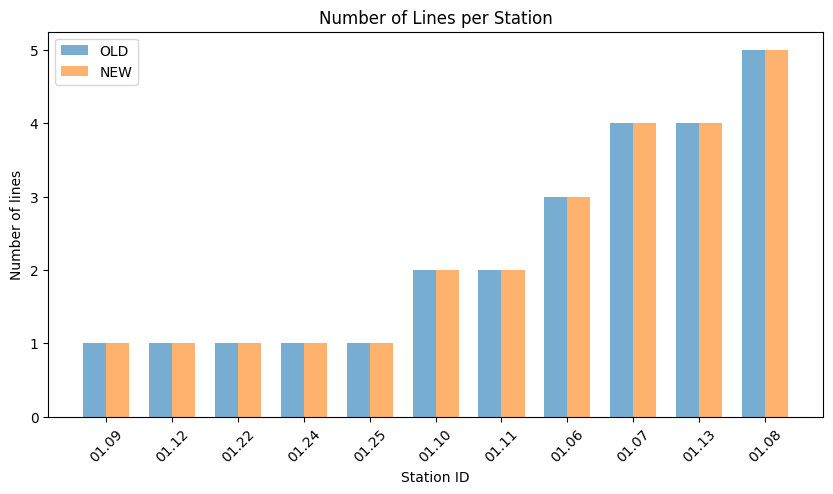

In [52]:
df_order_ref_plot = df_final.copy()
df_order_ref_plot['cnt_lines_New'] = df_order_ref_plot[['PRODUCT','StationID_P']].groupby('StationID_P').transform('nunique')
df_order_ref_plot['cnt_lines'] = df_order_ref_plot[['PRODUCT','STATION']].groupby('STATION').transform('nunique')
tmp_refs = df_order_ref_plot[['StationID_P','cnt_lines_New']].drop_duplicates()
tmp_refs.rename(columns={'StationID_P':'STATION'}, inplace=True)
tmp_refs = tmp_refs.merge(df_order_ref_plot[['STATION','cnt_lines']].drop_duplicates(), on='STATION', how='outer').fillna(0)
tmp_refs.sort_values(by='cnt_lines', ascending=True, inplace=True)
xlabel = 'Station ID'
ylabel = 'Number of lines'
title = 'Number of Lines per Station'
plot_final(tmp_refs, xlabel, ylabel, title, sort_by='cnt_lines', ascending=False)

In [53]:
import pickle

# Save to a pickle file
with open('x_Hexaly_1.pkl', 'wb') as f:
    pickle.dump(x_0, f)

NameError: name 'x_0' is not defined

In [ ]:
print(tmp_refs)

In [ ]:
station_product_initial = df_final.groupby('STATION')['PRODUCT'].apply(set).to_dict()
station_product_solution = df_final.groupby('StationID_P')['PRODUCT'].apply(set).to_dict()

In [ ]:
total_length_initial={s:0 for s in stations}
total_length_solution={s:0 for s in stations}

for s in stations:
    for p1 in station_product_initial[s]:
        total_length_initial[s] += product_frequency[p1]/speed[s]
        
    for p2 in station_product_solution[s]:
        total_length_solution[s] += product_frequency[p2]/speed[s]
    if total_length_solution[s] > 1.05*total_length_initial[s]:
        print(f"Length constraint value = {total_length_solution[s]}, has surpassed the Limit = {1.05*total_length_initial[s]}, on station {s}")

In [ ]:
print(product_frequency)

In [ ]:
print(total_length_solution)

In [ ]:
print(np.sum(total_length_solution[s] for s in stations))

In [ ]:
print(np.sum(total_length_initial[s] for s in stations))